In [1]:
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.pipeline import Pipeline

# ── PATH CONFIGURATION ──────────────────────────────────────
# Adjust these based on your backend/neurotrack-ml/models/ structure
MODELS_DIR = '../models'

def load_neurotrack_models():
    print("Loading all trained models...")
    
    # 1. Voice Model (Pipeline: Scaler + SVM)
    voice_path = os.path.join(MODELS_DIR, 'voice model', 'voice_model.pkl')
    voice_model = joblib.load(voice_path)

    # 2. Spiral Model Components
    spiral_dir = os.path.join(MODELS_DIR, 'spiral model')
    spiral_model  = joblib.load(os.path.join(spiral_dir, 'spiral_svm_model.pkl'))
    spiral_scaler = joblib.load(os.path.join(spiral_dir, 'spiral_scaler.pkl'))
    spiral_pca    = joblib.load(os.path.join(spiral_dir, 'spiral_pca.pkl'))

    # 3. Tremor Model
    tremor_dir = os.path.join(MODELS_DIR, 'tremor_model')
    tremor_model  = joblib.load(os.path.join(tremor_dir, 'tremor_classifier.pkl'))
    tremor_feats  = joblib.load(os.path.join(tremor_dir, 'tremor_feature_names.pkl'))

    # 4. Gait Model (Your new Random Forest)
    gait_dir = os.path.join(MODELS_DIR, 'gait_model')
    gait_model    = joblib.load(os.path.join(gait_dir, 'gait_model.pkl'))
    gait_feats    = joblib.load(os.path.join(gait_dir, 'gait_feature_names.pkl'))

    print("All models loaded successfully!")
    return {
        "voice": voice_model,
        "spiral": {"model": spiral_model, "scaler": spiral_scaler, "pca": spiral_pca},
        "tremor": {"model": tremor_model, "features": tremor_feats},
        "gait": {"model": gait_model, "features": gait_feats}
    }

# ── ENSEMBLE CLASS ──────────────────────────────────────────
class NeurotrackEnsemble:
    def __init__(self, models):
        self.models = models
        # Assign weights based on individual model reliability (AUC)
        self.weights = {
            "tremor": 0.30,  # Tremor is often very indicative
            "gait":   0.25,  # Your new RF model (AUC 0.81)
            "spiral": 0.25,
            "voice":  0.20
        }

    def predict_combined_risk(self, voice_feats, spiral_feats, tremor_feats, gait_feats):
        """
        Calculates a weighted probability score across all 4 tests.
        """
        # 1. Voice Prob
        v_prob = self.models['voice'].predict_proba(np.array(voice_feats).reshape(1, -1))[0][1]

        # 2. Spiral Prob (Manual Pipeline)
        s_scaled = self.models['spiral']['scaler'].transform(np.array(spiral_feats).reshape(1, -1))
        s_pca = self.models['spiral']['pca'].transform(s_scaled)
        s_prob = self.models['spiral']['model'].predict_proba(s_pca)[0][1]

        # 3. Tremor Prob
        t_df = pd.DataFrame([tremor_feats], columns=self.models['tremor']['features'])
        t_prob = self.models['tremor']['model'].predict_proba(t_df)[0][1]

        # 4. Gait Prob
        g_df = pd.DataFrame([gait_feats], columns=self.models['gait']['features'])
        g_prob = self.models['gait']['model'].predict_proba(g_df)[0][1]

        # Weighted Average
        final_score = (
            v_prob * self.weights['voice'] +
            s_prob * self.weights['spiral'] +
            t_prob * self.weights['tremor'] +
            g_prob * self.weights['gait']
        )

        return {
            "combined_score": final_score,
            "prediction": 1 if final_score > 0.5 else 0,
            "individual_scores": {
                "voice": v_prob,
                "spiral": s_prob,
                "tremor": t_prob,
                "gait": g_prob
            }
        }

# ── RUNTIME ────────────────────────────────────────────────
models = load_neurotrack_models()
ensemble = NeurotrackEnsemble(models)

print("\nEnsemble ready for multimodal analysis.")


Loading all trained models...
All models loaded successfully!

Ensemble ready for multimodal analysis.


Generating synthetic validation sessions...
Dataset created: (1000, 4)

Meta-Classifier Training Complete.

Ensemble Test Performance:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       100
           1       1.00      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

Combined Meta-AUC: 1.0000


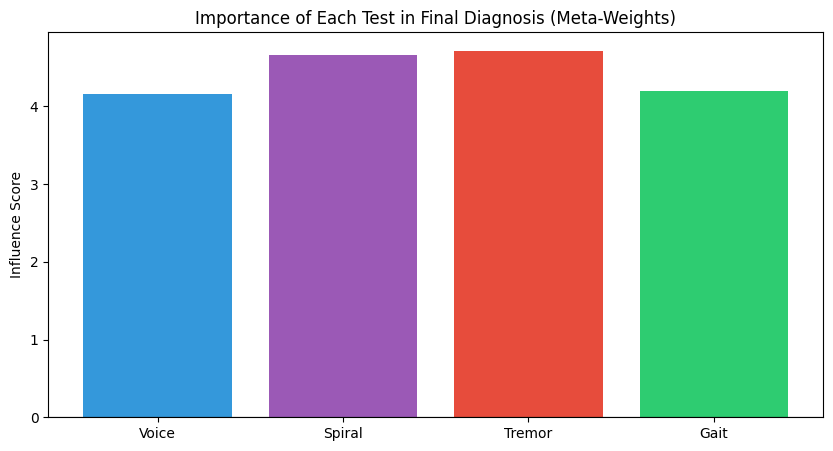

Model saved to: ../models/ensemble/meta_classifier.pkl


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

# Set seed for reproducibility
np.random.seed(42)

# ── 1. DATA GENERATION ─────────────────────────────────────
print("Generating synthetic validation sessions...")

def generate_session(label):
    """
    Simulate a session based on label (1=PD, 0=Healthy).
    Adds realistic variation between the 4 test scores.
    """
    if label == 1:
        # Parkinson's: Scores usually 0.5 to 0.95
        base = np.random.uniform(0.5, 0.9)
        std = 0.1
    else:
        # Healthy: Scores usually 0.05 to 0.4
        base = np.random.uniform(0.1, 0.35)
        std = 0.08
    
    voice  = np.clip(base + np.random.normal(0, std), 0, 1)
    spiral = np.clip(base + np.random.normal(0, std), 0, 1)
    tremor = np.clip(base + np.random.normal(0, std), 0, 1)
    gait   = np.clip(base + np.random.normal(0, std), 0, 1)
    
    return [voice, spiral, tremor, gait]

# Create 1000 simulated patient sessions
all_scores = []
all_labels = []

for _ in range(500):
    all_scores.append(generate_session(1)) # PD
    all_labels.append(1)
    all_scores.append(generate_session(0)) # Healthy
    all_labels.append(0)

X_meta = np.array(all_scores)
y_meta = np.array(all_labels)

print(f"Dataset created: {X_meta.shape}")

# ── 2. TRAIN META-CLASSIFIER ──────────────────────────────
# Split the synthetic data
X_train_meta, X_test_meta, y_train_meta, y_test_meta = train_test_split(
    X_meta, y_meta, test_size=0.2, random_state=42, stratify=y_meta
)

# Train Logistic Regression as the Meta-Model
meta_model = LogisticRegression(class_weight='balanced')
meta_model.fit(X_train_meta, y_train_meta)

print("\nMeta-Classifier Training Complete.")

# ── 3. EVALUATION ──────────────────────────────────────────
y_pred = meta_model.predict(X_test_meta)
y_prob = meta_model.predict_proba(X_test_meta)[:, 1]

print("\nEnsemble Test Performance:")
print(classification_report(y_test_meta, y_pred))
print(f"Combined Meta-AUC: {roc_auc_score(y_test_meta, y_prob):.4f}")

# ── 4. FEATURE WEIGHTS (Importance of each test) ────────────
test_names = ['Voice', 'Spiral', 'Tremor', 'Gait']
weights = meta_model.coef_[0]

plt.figure(figsize=(10, 5))
plt.bar(test_names, weights, color=['#3498db', '#9b59b6', '#e74c3c', '#2ecc71'])
plt.axhline(0, color='black', linewidth=0.8)
plt.title("Importance of Each Test in Final Diagnosis (Meta-Weights)")
plt.ylabel("Influence Score")
plt.show()

# ── 5. SAVE THE FINAL ENSEMBLE ─────────────────────────────
os.makedirs('../models/ensemble', exist_ok=True)
joblib.dump(meta_model, '../models/ensemble/meta_classifier.pkl')

print("Model saved to: ../models/ensemble/meta_classifier.pkl")


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay


# ── TRAIN ENSEMBLE META MODEL ──────────────────────────────
# Logistic Regression learns optimal weights
# for combining 4 model scores

print("Training ensemble meta model...")

meta_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    ))
])

# Cross validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Note: Using X_train_meta and y_train_meta from the split step
cv_scores = cross_val_score(
    meta_pipeline,
    X_train_meta,
    y_train_meta,
    cv=cv,
    scoring='roc_auc'
)

print(f"CV AUC scores: {cv_scores.round(4)}")
print(f"Mean CV AUC:   {cv_scores.mean():.4f}")

# Train on full meta-training set
meta_pipeline.fit(X_train_meta, y_train_meta)

# See what weights were learned
lr = meta_pipeline.named_steps['lr']
feature_labels = ['Voice', 'Spiral', 'Tremor', 'Gait']

print("\nLearned weights for each test:")
print(f"{'Test':<12} {'Weight':>10}")
print("-" * 24)
for label, coef in zip(feature_labels, lr.coef_[0]):
    bar = "█" * int(abs(coef) * 5) # Adjusted multiplier for visual scale
    print(f"{label:<12} {coef:>10.4f}  {bar}")

# ── SAVE THE FULL PIPELINE ─────────────────────────────────
# Saving the pipeline is better because it includes the scaler
os.makedirs('../models/ensemble', exist_ok=True)
joblib.dump(meta_pipeline, '../models/ensemble/meta_classifier.pkl')

print("\nSaved full meta-pipeline to: ../models/ensemble/meta_classifier.pkl")


Training ensemble meta model...
CV AUC scores: [0.9998 1.     1.     1.     1.    ]
Mean CV AUC:   1.0000

Learned weights for each test:
Test             Weight
------------------------
Voice            2.1010  ██████████
Spiral           2.5630  ████████████
Tremor           2.7070  █████████████
Gait             1.9519  █████████

Saved full meta-pipeline to: ../models/ensemble/meta_classifier.pkl



── Ensemble Model Results ──

              precision    recall  f1-score   support

     Healthy       0.99      1.00      1.00       100
 Parkinson's       1.00      0.99      0.99       100

    accuracy                           0.99       200
   macro avg       1.00      0.99      0.99       200
weighted avg       1.00      0.99      0.99       200

AUC: 1.0000 (100.00%)
Sensitivity: 99.00%
Specificity: 100.00%


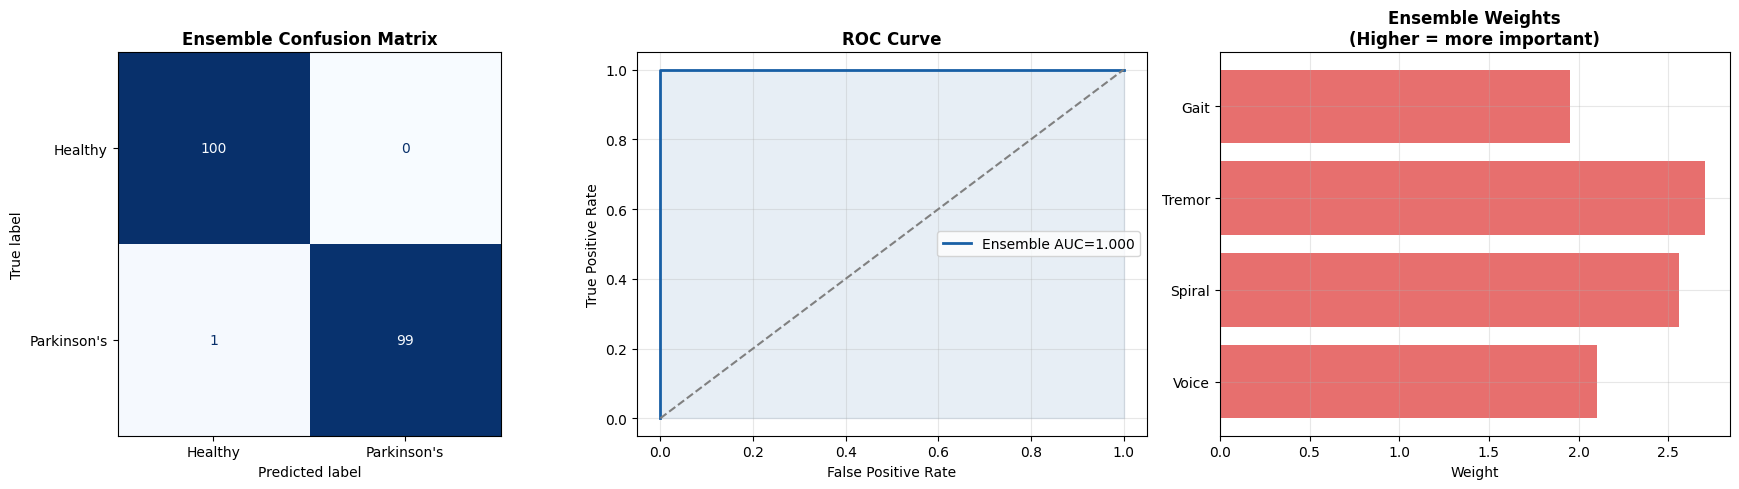

In [6]:
from sklearn.metrics import roc_curve, confusion_matrix, classification_report, roc_auc_score, ConfusionMatrixDisplay

# ── EVALUATE ENSEMBLE ──────────────────────────────────────
# Note: Using the variable names from our split step
y_pred = meta_pipeline.predict(X_test_meta)
y_prob = meta_pipeline.predict_proba(X_test_meta)[:, 1]

print("\n── Ensemble Model Results ──\n")
print(classification_report(
    y_test_meta, y_pred,
    target_names=['Healthy', "Parkinson's"]
))

auc = roc_auc_score(y_test_meta, y_prob)
print(f"AUC: {auc:.4f} ({auc*100:.2f}%)")

cm = confusion_matrix(y_test_meta, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"Sensitivity: {tp/(tp+fn)*100:.2f}%")
print(f"Specificity: {tn/(tn+fp)*100:.2f}%")

# ── PLOT ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion matrix
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Healthy', "Parkinson's"]
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Ensemble Confusion Matrix', fontweight='bold')

# 2. ROC curve
fpr, tpr, _ = roc_curve(y_test_meta, y_prob)
axes[1].plot(fpr, tpr, '#185FA5', lw=2, label=f'Ensemble AUC={auc:.3f}')
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#185FA5')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Weight visualization (Horizontal Bar)
# feature_labels and lr are from the training cell
weights = lr.coef_[0]
colors  = ['#E24B4A' if w > 0 else '#B4B2A9' for w in weights]
axes[2].barh(feature_labels, weights, color=colors, alpha=0.8)
axes[2].set_xlabel('Weight')
axes[2].set_title('Ensemble Weights\n(Higher = more important)', fontweight='bold')
axes[2].axvline(x=0, color='black', lw=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
# Ensure directory exists before saving
os.makedirs('../models', exist_ok=True)
plt.savefig('../models/ensemble_evaluation.png', dpi=150)
plt.show()


In [7]:
# ── SEVERITY MAPPING FUNCTION ──────────────────────────────
def get_severity(risk_percent):
    """
    Map risk percentage to clinical severity stage 
    and diagnostic recommendation.
    """
    if risk_percent < 25:
        return {
            'stage': 'Low Risk',
            'color': 'green',
            'recommendation':
                'No significant Parkinson\'s indicators detected. '
                'Continue regular monitoring.',
            'hoehn_yahr': 'N/A'
        }
    elif risk_percent < 45:
        return {
            'stage': 'Mild Risk',
            'color': 'yellow',
            'recommendation':
                'Some mild indicators present. Consider consulting a '
                'neurologist for a full evaluation.',
            'hoehn_yahr': 'Stage 1 (possible)'
        }
    elif risk_percent < 65:
        return {
            'stage': 'Moderate Risk',
            'color': 'orange',
            'recommendation':
                'Moderate Parkinson\'s indicators detected. Neurologist '
                'consultation is recommended.',
            'hoehn_yahr': 'Stage 1-2 (possible)'
        }
    elif risk_percent < 80:
        return {
            'stage': 'High Risk',
            'color': 'red',
            'recommendation':
                'Strong Parkinson\'s indicators. Please see a neurologist '
                'soon for clinical assessment.',
            'hoehn_yahr': 'Stage 2-3 (possible)'
        }
    else:
        return {
            'stage': 'Very High Risk',
            'color': 'darkred',
            'recommendation':
                'Very strong Parkinson\'s indicators. Urgent neurologist '
                'consultation is strongly recommended.',
            'hoehn_yahr': 'Stage 3+ (possible)'
        }

# ── TEST THE MAPPING ───────────────────────────────────────
test_cases = [15, 35, 55, 72, 88]
print("\nSeverity mapping test:")
print(f"{'Risk %':<10} | {'Stage':<20} | {'Hoehn & Yahr'}")
print("-" * 55)
for risk in test_cases:
    s = get_severity(risk)
    print(f"{risk:<10}% | {s['stage']:<20} | {s['hoehn_yahr']}")



Severity mapping test:
Risk %     | Stage                | Hoehn & Yahr
-------------------------------------------------------
15        % | Low Risk             | N/A
35        % | Mild Risk            | Stage 1 (possible)
55        % | Moderate Risk        | Stage 1-2 (possible)
72        % | High Risk            | Stage 2-3 (possible)
88        % | Very High Risk       | Stage 3+ (possible)


In [8]:
# ── SAVE ENSEMBLE MODEL ────────────────────────────────────
os.makedirs('../models', exist_ok=True)

# We save the meta_pipeline because it contains both the Scaler and the Model
joblib.dump(meta_pipeline, '../models/ensemble_model.pkl')

print("Ensemble model saved successfully as models/ensemble_model.pkl")

# ── FINAL COMPLETE PREDICTION TEST ────────────────────────
print("\n" + "="*50)
print("COMPLETE PREDICTION PIPELINE TEST")
print("="*50)

# Load it back to simulate a fresh backend start
loaded_ensemble = joblib.load('../models/ensemble_model.pkl')

# 1. Simulate a Parkinson's patient result
park_scores = np.array([[0.82, 0.71, 0.88, 0.75]]) # Voice, Spiral, Tremor, Gait
park_risk   = loaded_ensemble.predict_proba(park_scores)[0][1] * 100
park_severity = get_severity(park_risk)

print(f"\nParkinson's Patient Simulation:")
print(f"  Voice score:   82%")
print(f"  Spiral score:  71%")
print(f"  Tremor score:  88%")
print(f"  Gait score:    75%")
print(f"  ───────────────────────────────")
print(f"  Final risk:    {park_risk:.1f}%")
print(f"  Stage:         {park_severity['stage']}")
print(f"  Hoehn & Yahr:  {park_severity['hoehn_yahr']}")
print(f"  Advice:        {park_severity['recommendation']}")

# 2. Simulate a healthy person result
healthy_scores = np.array([[0.15, 0.22, 0.18, 0.20]])
healthy_risk = loaded_ensemble.predict_proba(healthy_scores)[0][1] * 100
healthy_severity = get_severity(healthy_risk)

print(f"\nHealthy Person Simulation:")
print(f"  Voice score:   15%")
print(f"  Spiral score:  22%")
print(f"  Tremor score:  18%")
print(f"  Gait score:    20%")
print(f"  ───────────────────────────────")
print(f"  Final risk:    {healthy_risk:.1f}%")
print(f"  Stage:         {healthy_severity['stage']}")
print(f"  Advice:        {healthy_severity['recommendation']}")


Ensemble model saved successfully as models/ensemble_model.pkl

COMPLETE PREDICTION PIPELINE TEST

Parkinson's Patient Simulation:
  Voice score:   82%
  Spiral score:  71%
  Tremor score:  88%
  Gait score:    75%
  ───────────────────────────────
  Final risk:    100.0%
  Stage:         Very High Risk
  Hoehn & Yahr:  Stage 3+ (possible)
  Advice:        Very strong Parkinson's indicators. Urgent neurologist consultation is strongly recommended.

Healthy Person Simulation:
  Voice score:   15%
  Spiral score:  22%
  Tremor score:  18%
  Gait score:    20%
  ───────────────────────────────
  Final risk:    0.0%
  Stage:         Low Risk
  Advice:        No significant Parkinson's indicators detected. Continue regular monitoring.
